In [1]:
### Plotting the analytic solution G(t, U, iw_n) and G(t(U), U, iw_n)
import numpy as np
import matplotlib.pyplot as plt
import utilities as ut
import itertools as it
import pickle
from pydlr import dlr
import cvxpy as cp
import SCE as sce
import WCE as wce
from _bary_rational import  AAA_adding0

In [2]:
beta = 50.0
Ntau = 401
Ns = 16
Nw = 50
Mat_fre = (2*np.linspace(0, Nw-1, Nw)+1)*np.pi/beta
wn = np.append(-np.flip(Mat_fre),Mat_fre)   # w_n = (2n+1)*pi/beta

In [3]:
t_values_sce = np.linspace(0,0.5,51)
t_values_wce = np.linspace(0,5,501)
Gij_iwn_sce = np.zeros((len(t_values_sce), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_wce = np.zeros((len(t_values_wce), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_hf = np.zeros((len(t_values_wce), wn.size, Ns, Ns), dtype ='complex')
for t in range(t_values_sce.size):
    Gij_iwn_sce[t]= sce.Gij_sce_t(2, Ns, 1.0, wn, t_values_sce[t])
for t in range(t_values_wce.size):
    Gij_iwn_hf[t], _ = wce.HF_G0(-t_values_wce[t], Ns, wn)
    Gij_iwn_wce[t]= wce.Gij_wce_U(2, Ns, 1.0, wn, beta, -t_values_wce[t])

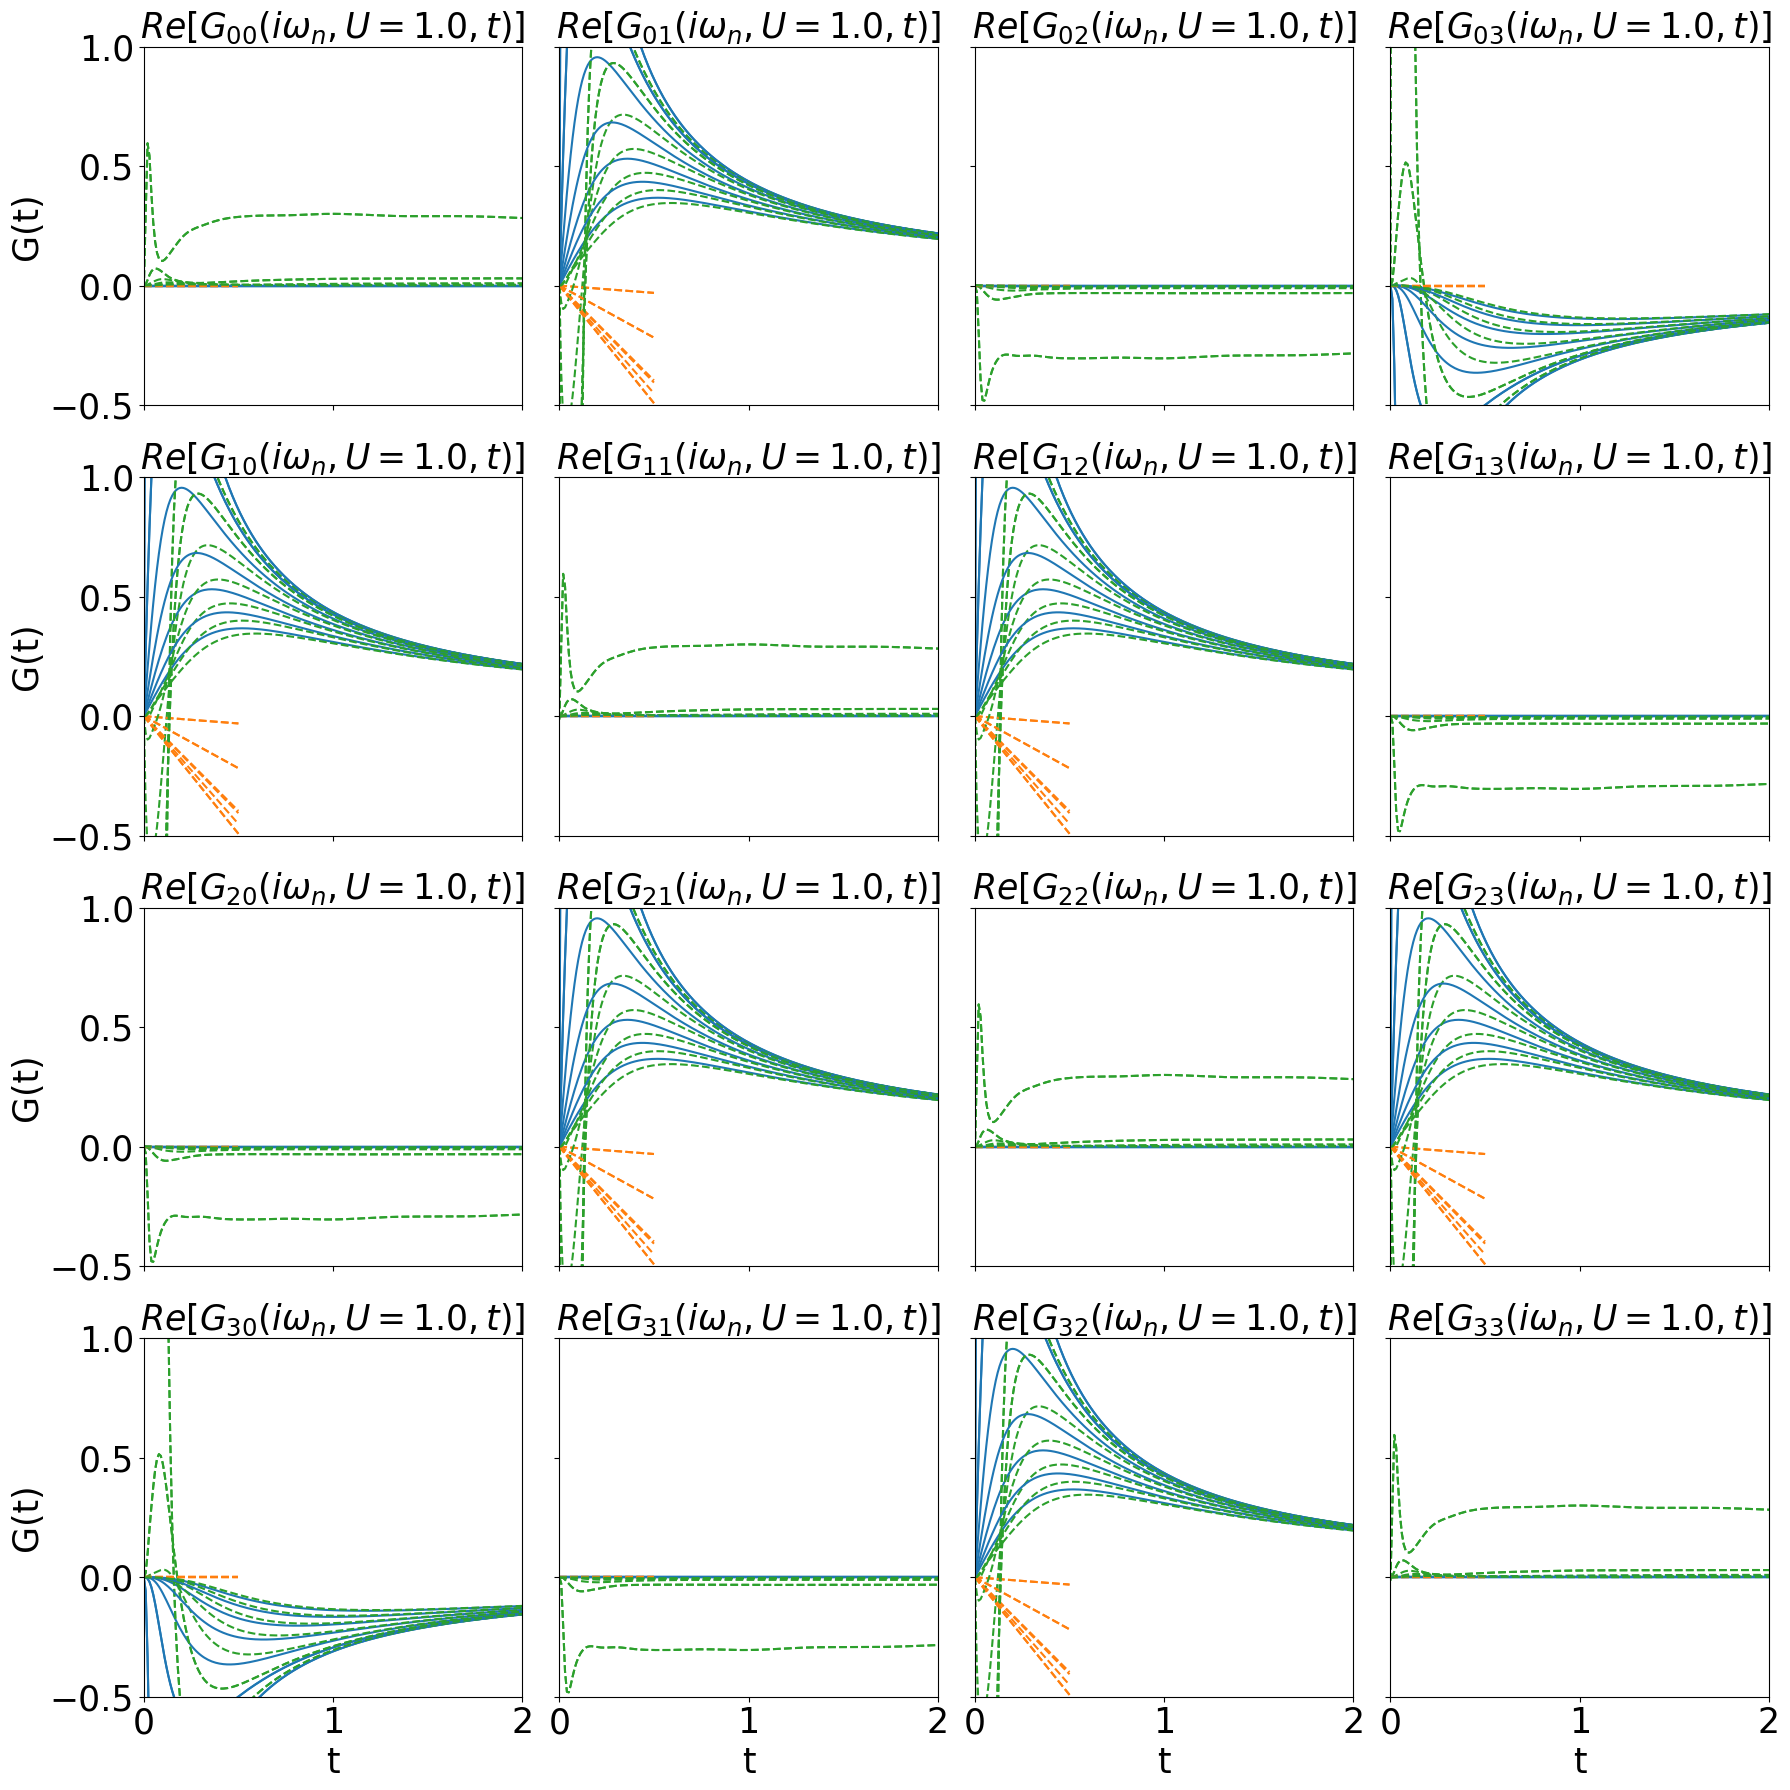

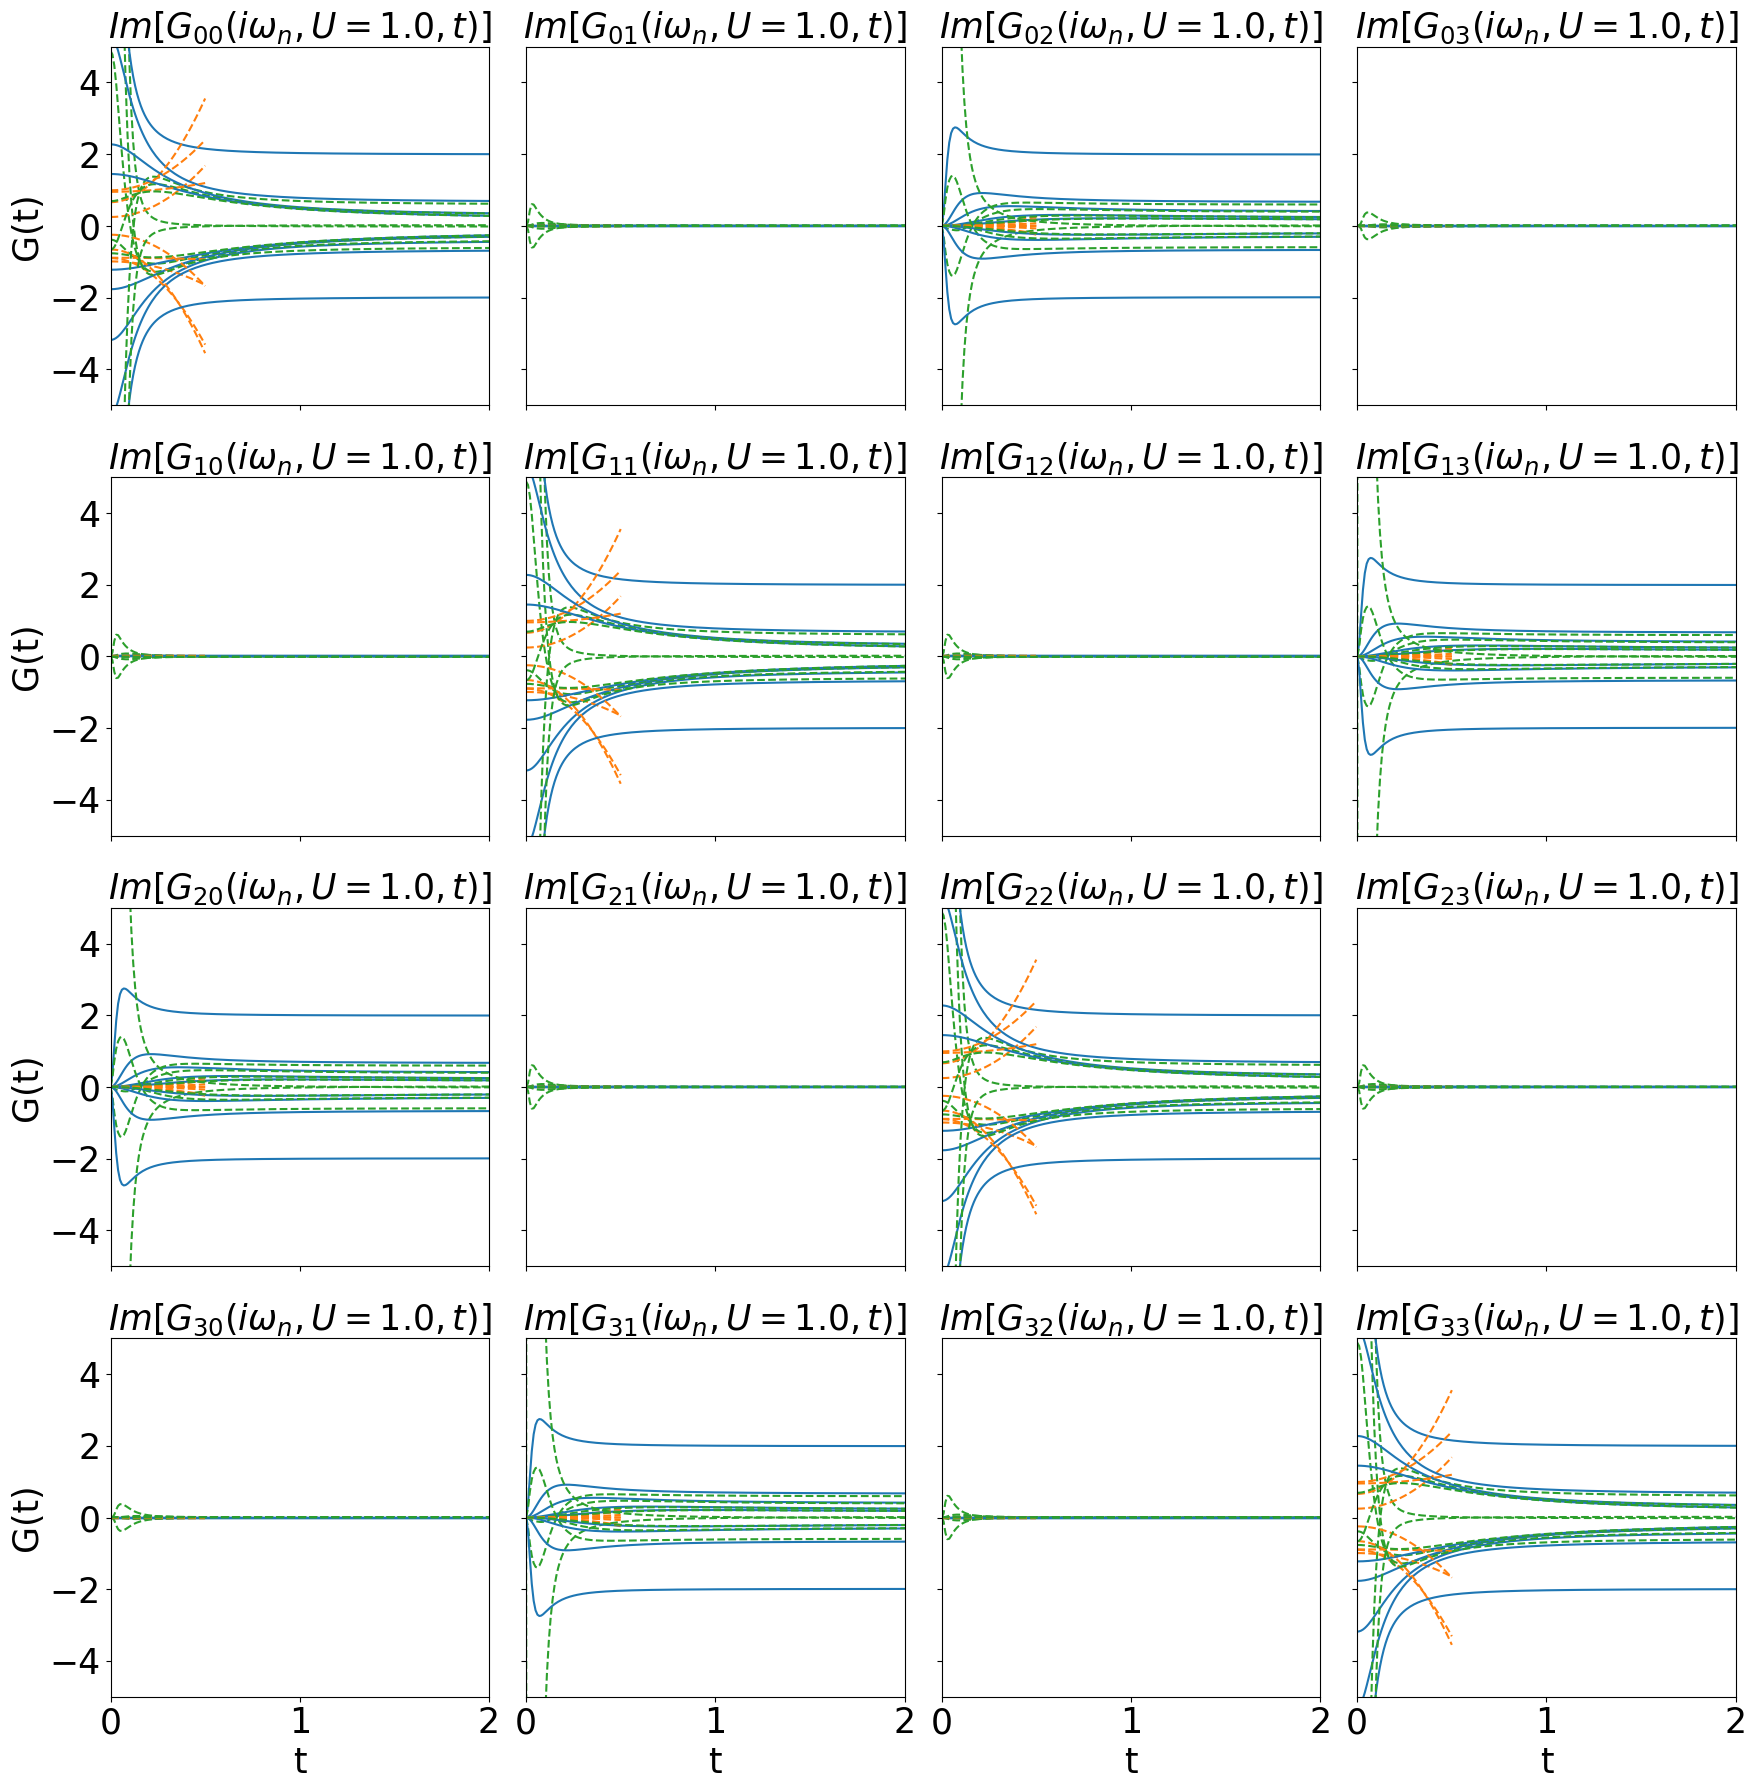

In [4]:
Ns_plot = 4

wn_id = [Nw+2, Nw+4, Nw+6, Nw+1, Nw, Nw-1, Nw-2, Nw-4, Nw-6]
fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        for k in wn_id:
            ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].real, 'C0')
            ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].real, 'C1--')
            ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].real, 'C2--')
        ax.set_title(r'$Re[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,1.0), fontsize=25)
        ax.tick_params(labelsize=25)

        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([-0.5,1])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        for k in wn_id:
            ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].imag, 'C0')
            ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].imag, 'C1--')
            ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].imag, 'C2--')
        ax.set_title(r'$Im[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,1.0), fontsize=25)
        ax.tick_params(labelsize=25)

        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([-5,5])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()



In [5]:
### Constructing the interpolation data 
tl = 1
idl = np.argmin(np.abs(t_values_wce - tl))

wce_t = t_values_wce[idl:]
wce_G = Gij_iwn_wce[idl:, :, :, :]
print("WCE data length=", wce_t.size)

tr = 0.05
idr = np.argmin(np.abs(t_values_sce - tr))

sce_t = t_values_sce[:idr ]
sce_G = Gij_iwn_sce[:idr, :, :, :]

t_app = np.concatenate([wce_t , sce_t ], axis=0)
G_app = np.concatenate([wce_G , sce_G ], axis=0)

print("SCE data length=", sce_t.size)

WCE data length= 401
SCE data length= 5


In [6]:
### AAA interpolation 
err_bar1 = 1e-3
Gij_iwn_interp = np.zeros((t_values_wce.size, wn.size, Ns_plot, Ns_plot), dtype = complex)

for n in range(wn.size):
    print("n=", n)
    for i in range(Ns_plot):
        for j in range(Ns_plot):
            if (-1)**(i+j) >0:
                r = AAA_adding0(t_app, 1j*G_app[:, n, i, j].imag,  rtol=err_bar1, max_terms= 40)
                
            else:
                r = AAA_adding0(t_app, G_app[:, n, i, j].real,  rtol=err_bar1, max_terms= 40)
            Gij_iwn_interp[:, n, i, j] = r(t_values_wce)

n= 0
n= 1
n= 2
n= 3
n= 4
n= 5
n= 6
n= 7
n= 8
n= 9
n= 10
n= 11
n= 12
n= 13
n= 14
n= 15
n= 16
n= 17
n= 18
n= 19
n= 20
n= 21
n= 22
n= 23
n= 24
n= 25
n= 26
n= 27
n= 28
n= 29
n= 30
n= 31
n= 32
n= 33
n= 34
n= 35
n= 36
n= 37
n= 38
n= 39
n= 40
n= 41
n= 42
n= 43
n= 44
n= 45
n= 46
n= 47
n= 48
n= 49
n= 50
n= 51
n= 52
n= 53
n= 54
n= 55
n= 56
n= 57
n= 58
n= 59
n= 60
n= 61
n= 62
n= 63
n= 64
n= 65
n= 66
n= 67
n= 68
n= 69
n= 70
n= 71
n= 72
n= 73
n= 74
n= 75
n= 76
n= 77
n= 78
n= 79
n= 80
n= 81
n= 82
n= 83
n= 84
n= 85
n= 86
n= 87
n= 88
n= 89
n= 90
n= 91
n= 92
n= 93
n= 94
n= 95
n= 96
n= 97
n= 98
n= 99


[52, 54, 56, 51, 50, 49, 48, 46, 44]


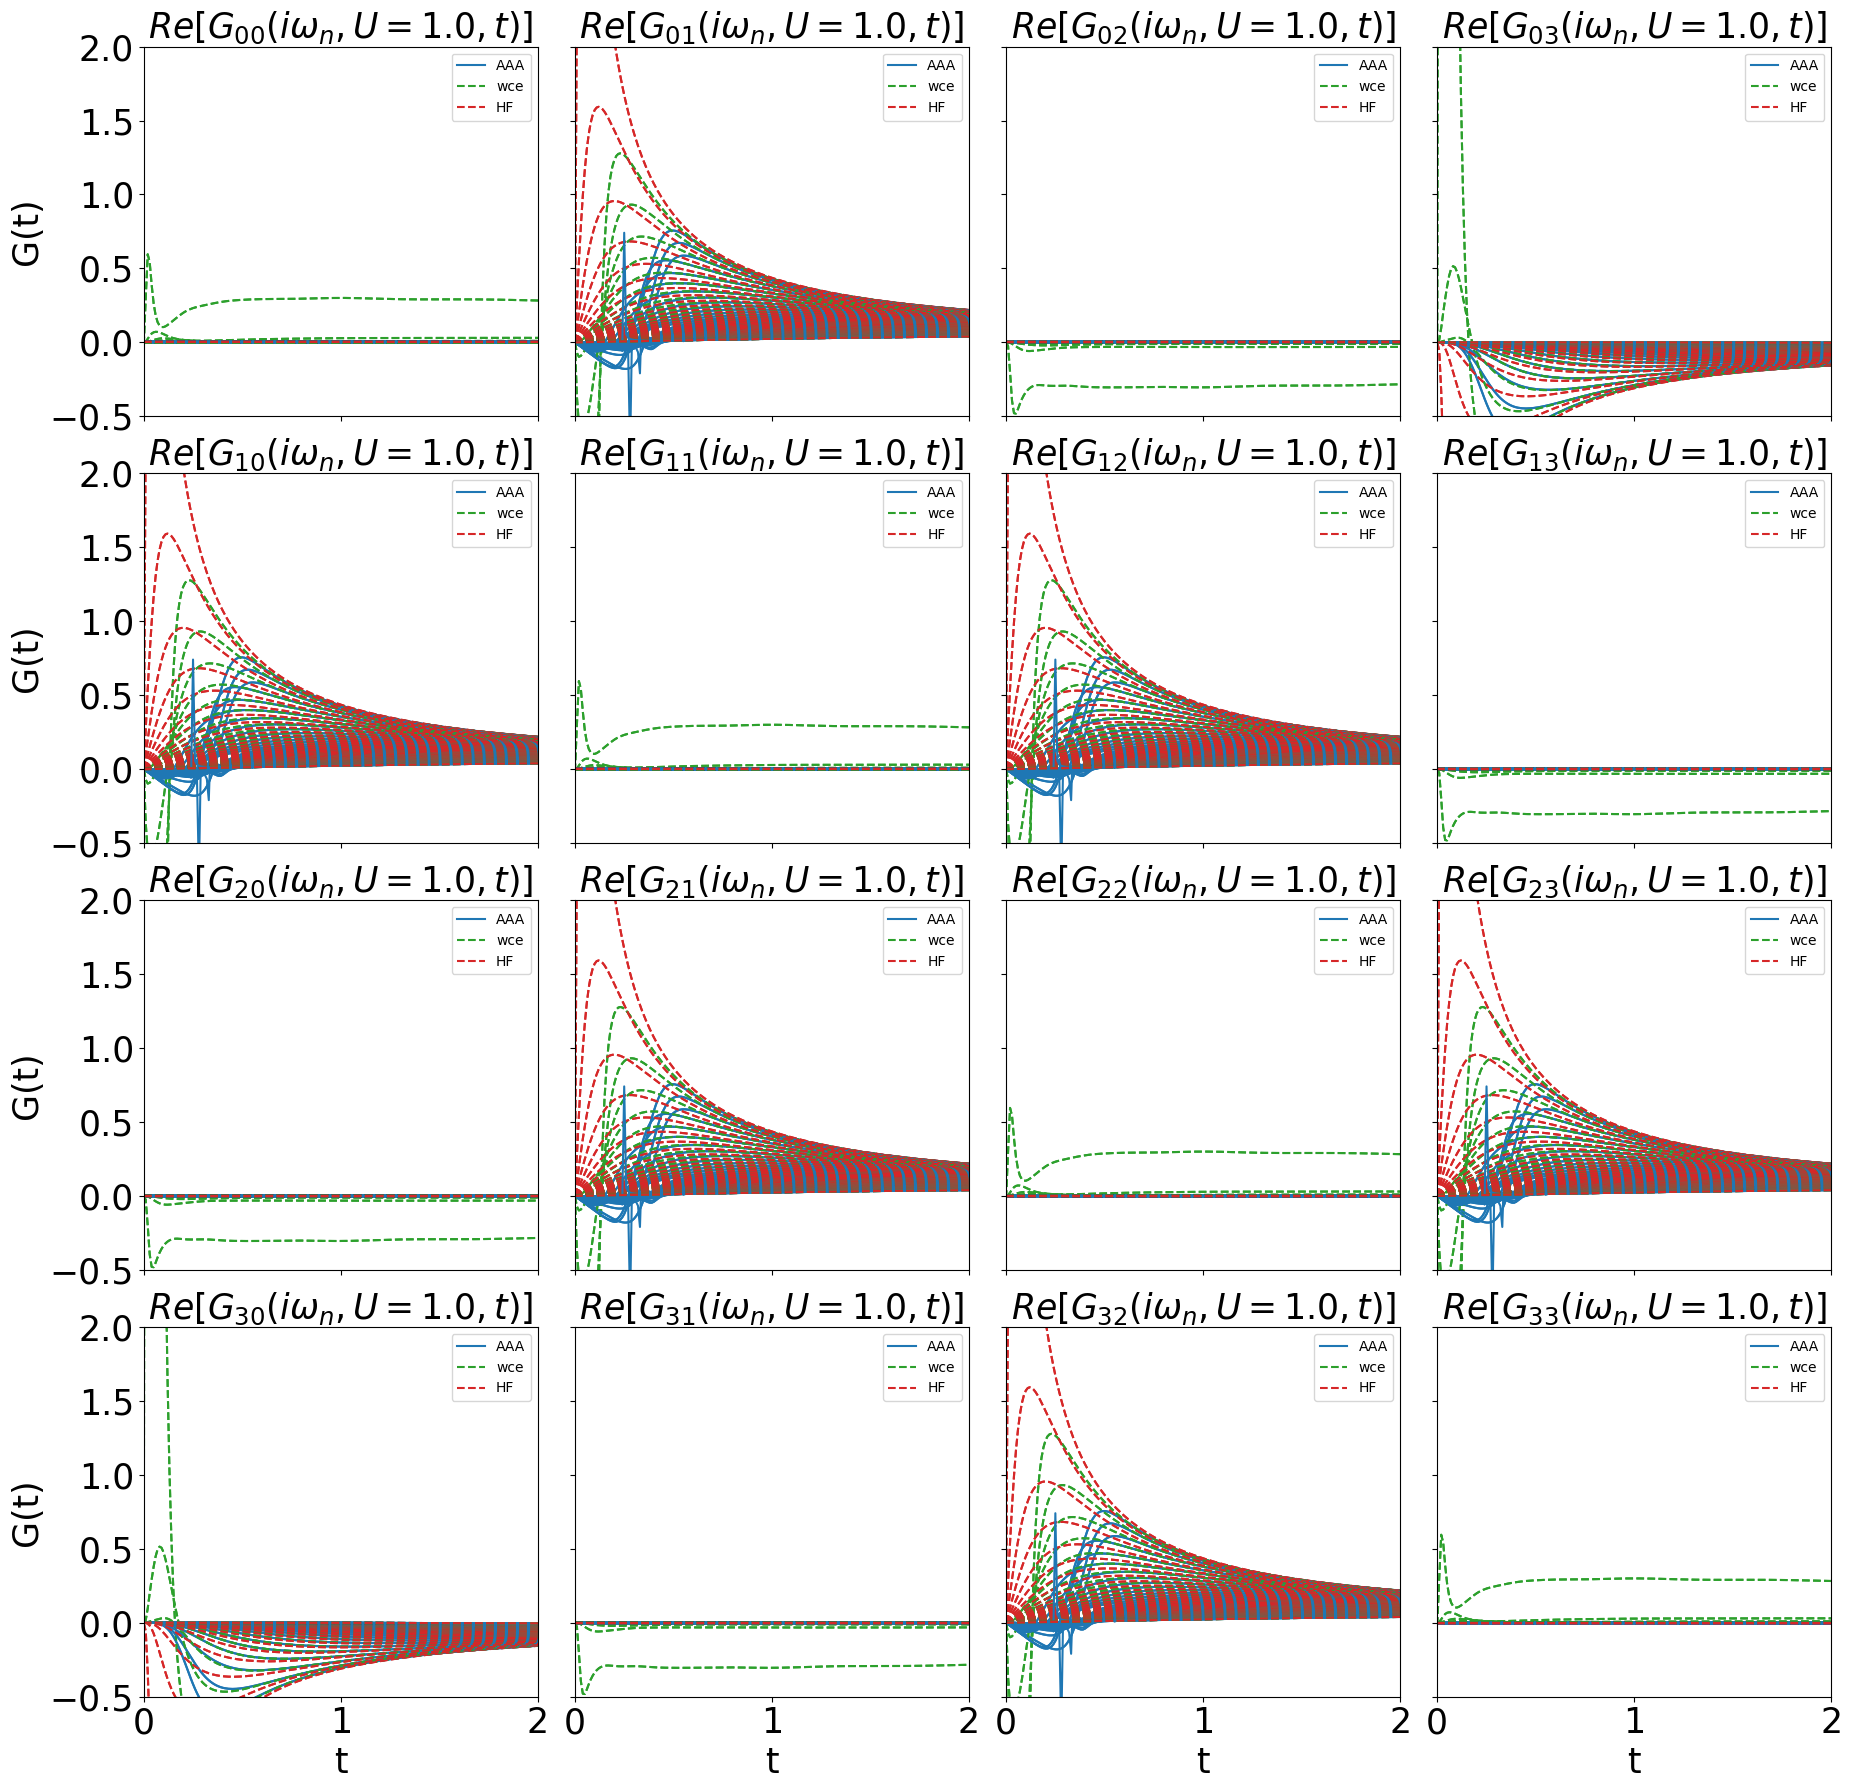

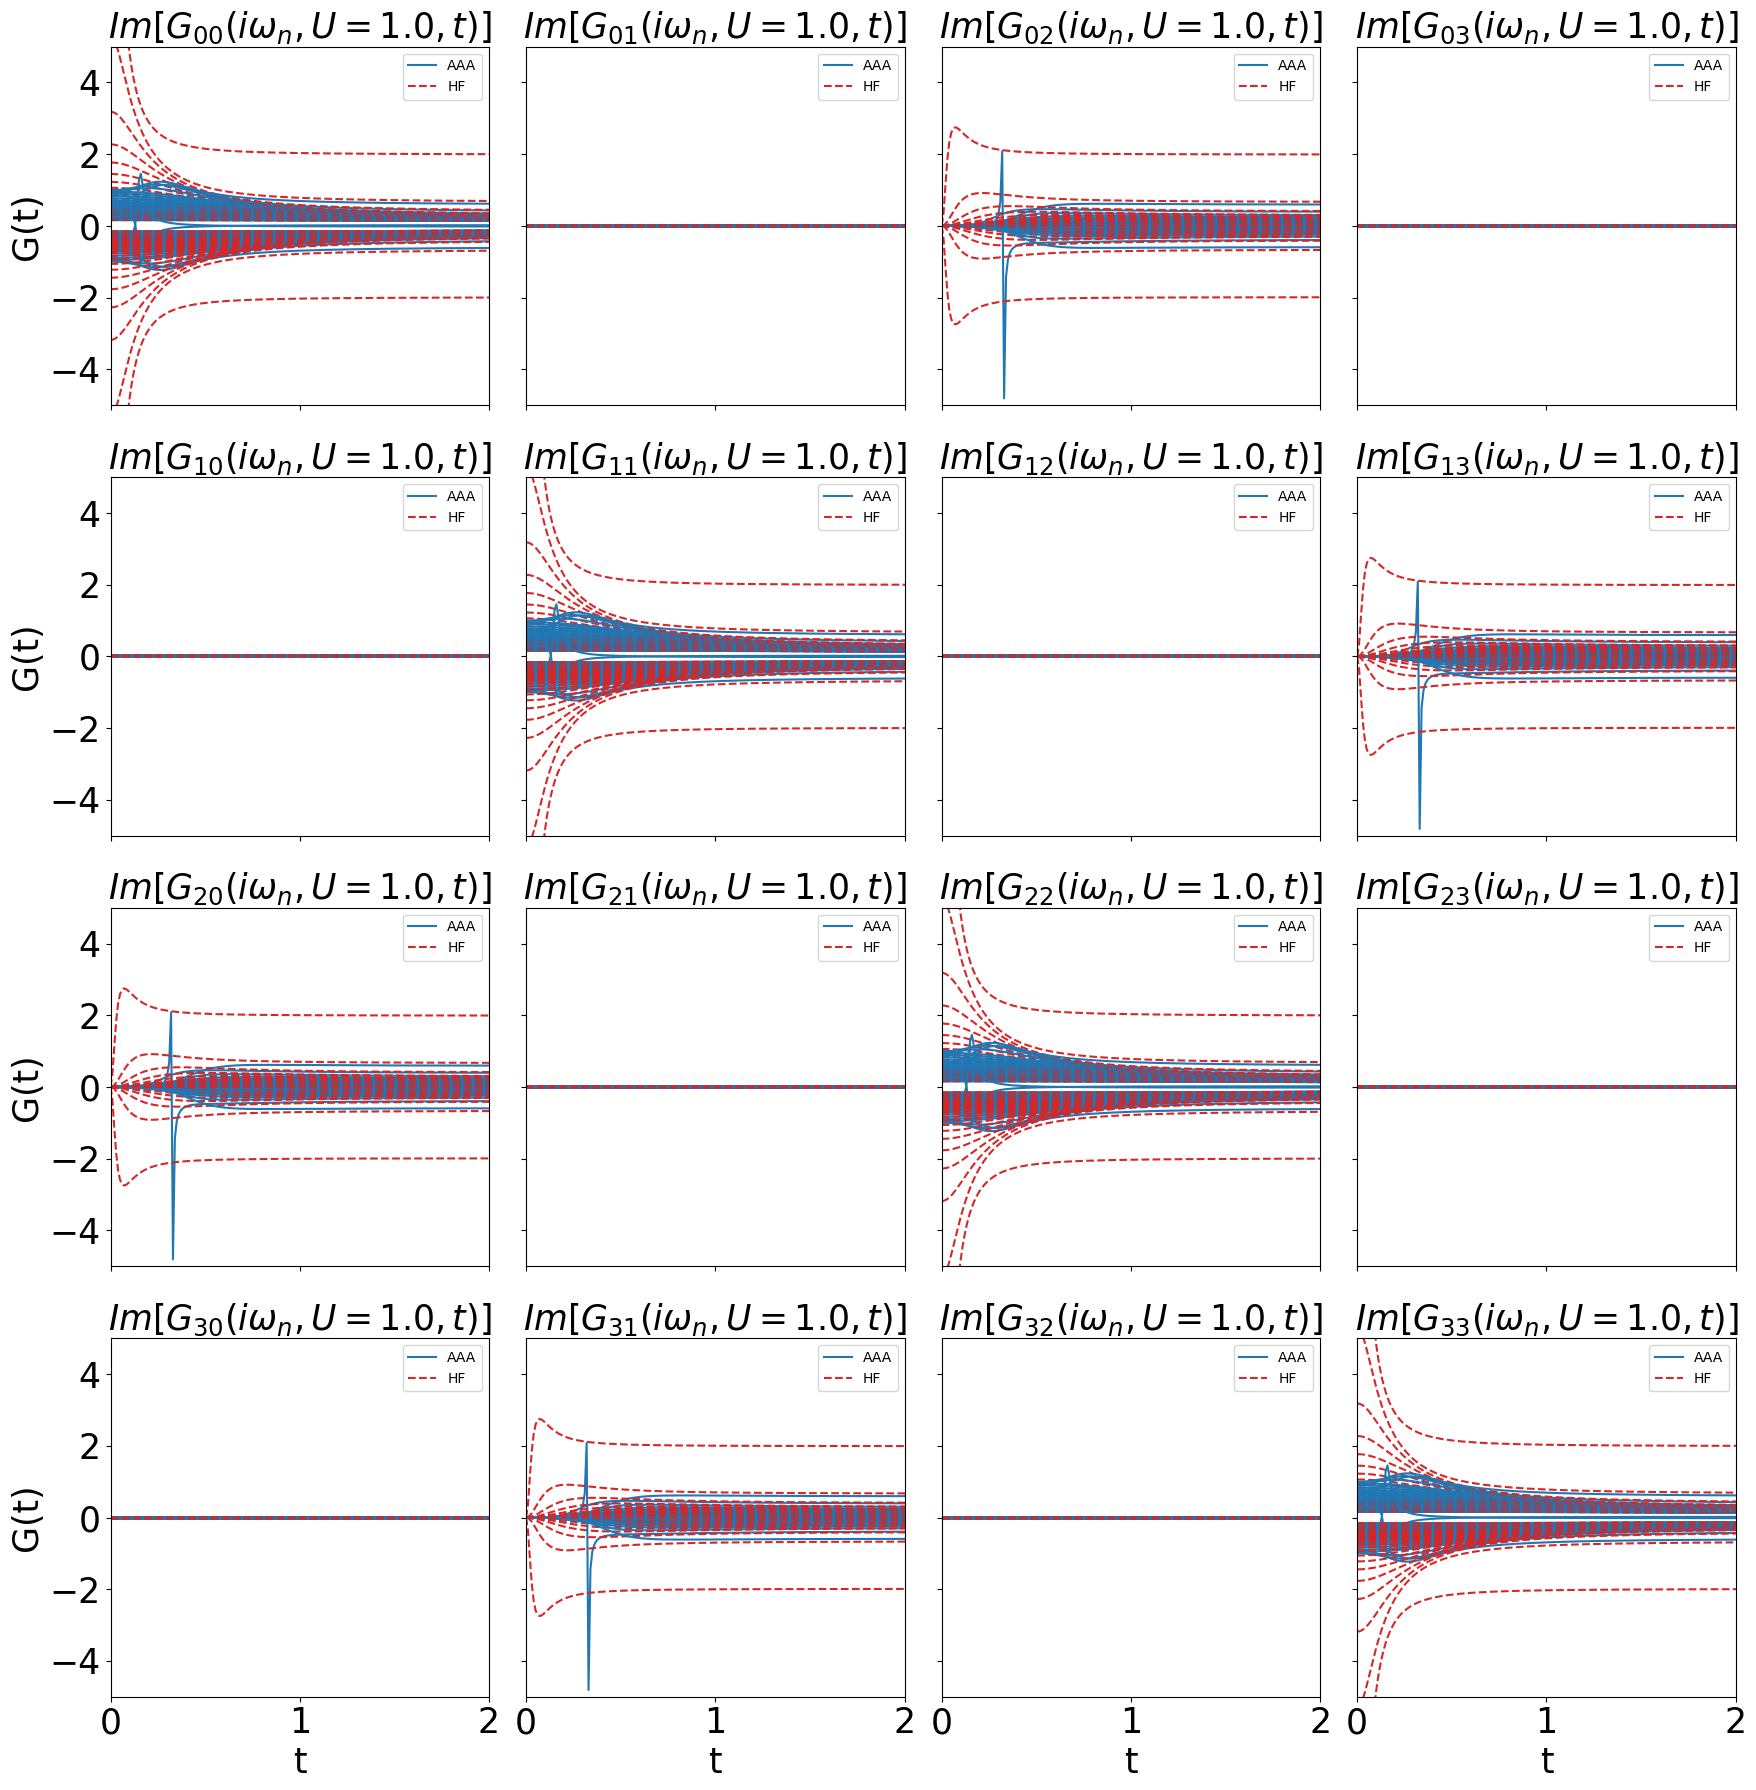

In [7]:
Ns_plot = 4

wn_id = [Nw+2, Nw+4, Nw+6, Nw+1, Nw, Nw-1, Nw-2, Nw-4, Nw-6]
print(wn_id)
fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        # for k in wn_id:
        for k in range(wn.size):
            ax.plot(t_values_wce, Gij_iwn_interp[:, k, i ,j ].real, 'C0')
            # ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].real, 'C1--')
            ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].real, 'C2--')
            ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].real, 'C3--')

        ax.plot(t_values_wce, Gij_iwn_interp[:, k, i ,j ].real, 'C0', label= 'AAA')
        # ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].real, 'C1--', label= 'sce')
        ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].real, 'C2--', label= 'wce')
        ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].real, 'C3--', label= 'HF')
        ax.set_title(r'$Re[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,1.0), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend()
        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([-0.5,2])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(Ns_plot, Ns_plot, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns_plot):
    for j in range(Ns_plot):
        ax = axes[i, j]
        # for k in wn_id:
        for k in range(wn.size):
            ax.plot(t_values_wce, Gij_iwn_interp[:, k, i ,j ].imag, 'C0')
            # ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].imag, 'C1--')
            # ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].imag, 'C2--')
            ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].imag, 'C3--')
            
        ax.plot(t_values_wce, Gij_iwn_interp[:, k, i ,j ].imag, 'C0', label= 'AAA')
        # ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].imag, 'C1--', label= 'sce')
        # ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].imag, 'C2--', label= 'wce')
        ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].imag, 'C3--', label= 'HF')
        ax.set_title(r'$Im[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,1.0), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend()
        if i == Ns_plot - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([-5,5])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()